# Representation Theory Project: $\mathfrak{sl}_2$ and $\mathfrak{sl}_3$

This project arose from the need to firmly understand the topics covered in Maria's 601 course regarding the Lie algebras $\mathfrak{sl}_2$ and $\mathfrak{sl}_3$.

## 1. Lie Algebra Representations and $\mathfrak{sl}_2$

A representation of a Lie algebra like $\mathfrak{sl}_2$ is a linear map $\rho: \mathfrak{sl}_2 \to \mathfrak{gl}_n$ (the general linear Lie algebra of $n \times n$ matrices) that preserves the Lie bracket (the commutator).

This means that for any $X, Y \in \mathfrak{sl}_2$:

$$ \rho([X, Y]) = [\rho(X), \rho(Y)] = \rho(X)\rho(Y) - \rho(Y)\rho(X) $$

In [ ]:
# Create the Lie algebra sl_2 and its standard defining representation using Sage's LieAlgebra
sl2 = LieAlgebra(QQ, cartan_type=['A', 1], representation='matrix')

# For Cartan type A1, the generators are returned in order: E, F, H.
E, F, H = sl2.gens()

print("Generator E:\n", E.matrix())
print("Generator F:\n", F.matrix())
print("Generator H:\n", H.matrix())

print("\n--- Verifying Fundamental Relations in the 2x2 standard representation ---")
print("[E, E] == 0 :", sl2[E, E] == sl2.zero())
print("[E, F] == H :", sl2[E, F] == H)
print("[H, E] == 2E:", sl2[H, E] == 2*E)
print("[H, F] == -2F:", sl2[H, F] == -2*F)


## 2. The Classification of Irreducible Representations

Following Fulton & Harris (Claim 11.5 - 11.8), we can classify all finite-dimensional irreducible representations of $\mathfrak{sl}_2$ based on the action of $H$.

By writing down a basis for an arbitrary irreducible representation $V$ and examining where $H$, $E$ (F&H's $X$), and $F$ (F&H's $Y$) map each vector, we reach a powerful conclusion:
1. **Highest Weight**: Every irreducible representation $V$ is completely determined by a single non-negative integer $n$. We call this representation $V^{(n)}$.
2. **Dimension**: The dimension of $V^{(n)}$ is $n + 1$.
3. **Weight Spaces**: The eigenvalues of $H$ on $V^{(n)}$ (the "weights") form a contiguous string of integers differing by 2 and symmetric about the origin:
   $$ n, n - 2, \dots, -n + 2, -n $$
4. **Multiplicity-Free**: Every eigenspace $V_{\alpha}$ of $H$ is exactly **1-dimensional**.

*Useful Corollary*: Any representation $V$ of $\mathfrak{sl}_2$ where the eigenvalues of $H$ share the same parity and occur with multiplicity 1 is necessarily irreducible!

## 3. Realizing $V^{(n)}$ as Symmetric Powers

We can explicitly construct $V^{(n)}$ for any $n$ using the **standard representation** $V \cong \mathbb{C}^2$. 

Let $x$ and $y$ be the standard basis for $\mathbb{C}^2$, such that $H(x) = x$ and $H(y) = -y$. The generators act as differential operators:
$$ E = x\partial_y, \quad F = y\partial_x, \quad H = x\partial_x - y\partial_y $$

The $n$-th symmetric power $\text{Sym}^n(V)$ has a natural basis of dimension $n+1$:
$$ \{x^n, x^{n-1}y, x^{n-2}y^2, \dots, y^n\} $$

Applying our operators to a general basis vector $v_k = x^{n-k}y^k$ (where $0 \le k \le n$):
*   $$H(v_k) = (n - k)x^{n-k}y^k - k x^{n-k}y^k = (n - 2k)v_k $$
*   $$E(v_k) = k x^{n-k+1}y^{k-1} = k v_{k-1} $$
*   $$F(v_k) = (n - k)x^{n-k-1}y^{k+1} = (n - k)v_{k+1} $$

This perfectly matches the eigenvalue spectrum $n, n-2, \dots, -n$ with multiplicity 1. Therefore, $\text{Sym}^n(V)$ **is** exactly the irreducible representation $V^{(n)}$.

### Low-Dimensional Examples and Common Names

*   **$n=0$ (Trivial Representation)**: Dimension 1. $\text{Sym}^0(V) \cong \mathbb{C}$. $H$ eigenvalue: $0$.
*   **$n=1$ (Standard Representation)**: Dimension 2. $\text{Sym}^1(V) = V$. $H$ eigenvalues: $1, -1$.
*   **$n=2$ (Adjoint Representation)**: Dimension 3. $\text{Sym}^2(V)$. $H$ eigenvalues: $2, 0, -2$. (This is completely isomorphic to the adjoint representation $\text{ad}$ acting on the basis $(E, H, F)$, just under a different basis mapping).

Let's write a python function to generate the explicit matrices for $V^{(n)}$!

In [ ]:
def sl2_irrep(n):
    """
    Constructs the matrices for E, F, H for the irreducible representation V^(n) 
    of sl_2 using the symmetric power basis v_k = x^{n-k} y^k for k=0..n.
    """
    dim = n + 1
    mat_H = matrix(QQ, dim, dim)
    mat_E = matrix(QQ, dim, dim)
    mat_F = matrix(QQ, dim, dim)
    
    for k in range(dim):
        # H(v_k) = (n - 2k) v_k
        mat_H[k, k] = n - 2*k
        
        # E(v_k) = k * v_{k-1}
        if k > 0:
            mat_E[k-1, k] = k
            
        # F(v_k) = (n - k) * v_{k+1}
        if k < n:
            mat_F[k+1, k] = n - k
            
    return mat_E, mat_F, mat_H

def verify_sl2_relations(E, F, H):
    """Verifies the fundamental brackets [E,F]=H, [H,E]=2E, [H,F]=-2F"""
    def bracket(A, B): return A*B - B*A
    
    b1 = bracket(E, F) == H
    b2 = bracket(H, E) == 2*E
    b3 = bracket(H, F) == -2*F
    return b1 and b2 and b3


## 4. Demonstrations for Low $n$

In [ ]:
for n in range(6):  # Test n = 0, 1, 2, 3, 4, 5
    E_n, F_n, H_n = sl2_irrep(n)
    
    print(f"========== V^({n}) ==========")
    print(f"Dimension: {n+1}")
    print("Relations Hold:", verify_sl2_relations(E_n, F_n, H_n))
    print("Eigenvalues of H (Weights):", H_n.diagonal())
    
    # For n <= 2, let's explicitly print the matrices so we can compare 
    # with our previous definitions of Trivial, Standard, and Adjoint!
    if n <= 2:
        print("\nMatrix H:")
        print(H_n)
        print("Matrix E:")
        print(E_n)
        print("Matrix F:")
        print(F_n)
        
    print("\n")


## 5. Isomorphisms and Change of Basis

In the course notes (page 26), the adjoint representation is constructed explicitly by analyzing the action of the Lie bracket on the ordered basis $(E, F, H)$. The resulting matrices are:
$$ E_{\text{notes}} = \begin{pmatrix} 0 & 0 & -2 \\ 0 & 0 & 0 \\ 0 & 1 & 0 \end{pmatrix}, \quad F_{\text{notes}} = \begin{pmatrix} 0 & 0 & 0 \\ 0 & 0 & 2 \\ -1 & 0 & 0 \end{pmatrix}, \quad H_{\text{notes}} = \begin{pmatrix} 2 & 0 & 0 \\ 0 & -2 & 0 \\ 0 & 0 & 0 \end{pmatrix} $$
*(Note: The notes contain a typo indicating $E \mapsto \dots$ for the third matrix, but it is clear from the eigenvalues $(2, -2, 0)$ that this matrix represents $H$.)*

Comparing this to the matrices we generated for $n=2$ (which is structurally the adjoint representation), they look different! Our matrices were built inside the symmetric power basis $(x^2, xy, y^2)$.

Because both representations describe the same 3-dimensional irreducible representation $V^{(2)}$, they must be **isomorphic**, meaning there exists an invertible change-of-basis matrix $P$ connecting them. We can decode this matrix $P$ by matching the weights of the elements:
1. $E$ (weight 2) $\mapsto k_1 x^2$
2. $F$ (weight -2) $\mapsto k_2 y^2$
3. $H$ (weight 0) $\mapsto k_3 xy$

Solving for the constants using the $[E, F]=H$ brackets reveals that we can define the mapping $T: V^{(2)} \to V_{\text{notes}}$ structurally:
* $x^2 \mapsto -2E$
* $xy \mapsto H$
* $y^2 \mapsto 2F$

This gives us the coordinate transformation matrix $P$ mapping the $(x^2, xy, y^2)$ coordinate space to the $(E, F, H)$ coordinate space:
$$ P = \begin{pmatrix} -2 & 0 & 0 \\ 0 & 0 & 2 \\ 0 & 1 & 0 \end{pmatrix} $$
*(Notice how the middle rows and columns are "swapped" because our basis orders weights monotonically as $2, 0, -2$, while the notes ordered them $2, -2, 0$ by selecting the sequence $(E, F, H)$.)*

Let's verify computationally that $P^{-1} M_{\text{notes}} P = M_{\text{ours}}$!

In [ ]:
print("--- Verifying Change of Basis for Adjoint (n=2) ---")
# 1. Define the matrices exactly as written in the notes
E_notes = matrix(QQ, [[0, 0, -2], [0, 0, 0], [0, 1, 0]])
F_notes = matrix(QQ, [[0, 0, 0], [0, 0, 2], [-1, 0, 0]])
H_notes = matrix(QQ, [[2, 0, 0], [0, -2, 0], [0, 0, 0]])

# 2. Grab our symmetric power matrices for n=2
E_ours, F_ours, H_ours = sl2_irrep(2)

# 3. Define the change of basis matrix P mapping (x^2, xy, y^2) -> (E, F, H)
# Column 1 (x^2): [-2, 0, 0]^T   (since x^2 maps to -2E, the first basis vector)
# Column 2 (xy):  [0, 0, 1]^T    (since xy maps to H, the third basis vector)
# Column 3 (y^2): [0, 2, 0]^T    (since y^2 maps to 2F, twice the second basis vector)
P = matrix(QQ, [
    [-2,  0,  0],
    [ 0,  0,  2],
    [ 0,  1,  0]
])

print("Change of basis matrix P:")
print(P)
print("\nP is invertible:", P.is_invertible())

# 4. Verify the isomorphism: P^(-1) * M_notes * P == M_ours
print("\nIs P^(-1) * E_notes * P == E_ours? :", P.inverse() * E_notes * P == E_ours)
print("Is P^(-1) * F_notes * P == F_ours? :", P.inverse() * F_notes * P == F_ours)
print("Is P^(-1) * H_notes * P == H_ours? :", P.inverse() * H_notes * P == H_ours)


## 6. Graphing Representations (Exercises from Homework 3)

In Homework 3, we are asked to visualize irreducible representations of $\mathfrak{sl}_2$ as graphs. 
A highly effective combinatorial way to visualize $V^{(n)}$ is by treating the **weight spaces as nodes** and the **action of the generators as directed edges**.

Specifically:
- **Nodes**: The possible eigenvalues (weights) of $H$.
- **$H$ Edges**: Self-loops on each node, representing that $H$ scales the vector by its weight.
- **$E$ Edges**: Directed edges moving from weight $w$ to weight $w + 2$.
- **$F$ Edges**: Directed edges moving from weight $w$ to weight $w - 2$.

Below, we write a general purpose function `plot_sl2_representation(n)` that algorithmically generates this exact graph for any $V^{(n)}$, and specifically use it to answer **Part (a)** of the homework exercise by graphing $V^{(3)}$.

*(Bonus: The combinatorial structure underlying these graphs visually mirrors the theory of "Crystal Graphs", which describe Kashiwara operators $e_i$ and $f_i$ acting on tensor structures!)*

In [ ]:
def plot_sl2_custom(n, use_words=False):
    """
    Plots the weight diagram for V^(n) with custom Bezier paths for perfect edge styling!
    """
    p = Graphics()
    
    weights = [n - 2*k for k in range(n + 1)]
    
    # Maps weight directly to symmetric words of 1s and 2s
    def get_node_label(w):
        if not use_words:
            return str(w)
        k = (n - w) // 2
        return "1"*(n-k) + "2"*k
        
    for w in weights:
        # H loop: Open, rounded, bottom-aligned loop
        h_color = 'purple'
        # Using bezier paths to draw exactly what we want
        p += bezier_path([[(w-0.1, -0.4), (w-0.5, -1.2), (w+0.5, -1.2), (w+0.1, -0.4)]], color=h_color, thickness=1.5)
        p += text("H", (w, -1.3), color=h_color, fontsize=12, vertical_alignment='top')
        
        # Node circle and text
        p += circle((w, 0), 0.35, fill=True, color='lightblue', zorder=2)
        p += circle((w, 0), 0.35, color='black', thickness=1.5, zorder=3)
        p += text(get_node_label(w), (w, 0), color='black', fontsize=12 if not use_words else 10, zorder=4)
        
    for i in range(len(weights) - 1):
        w_curr = weights[i]     # e.g., 3
        w_next = weights[i+1]   # e.g., 1 (moves right-to-left physically on our x-axis!)
        
        # F edge (Lowering): moves from w_curr to w_next (Right to Left).
        # F labeling on top, concave upwards (y>0).
        f_color = 'red'
        p += bezier_path([[(w_curr, 0.4), (w_curr - 0.5, 0.9), (w_next + 0.5, 0.9), (w_next, 0.4)]], color=f_color, thickness=1.5, zorder=1)
        p += text("<-- F", ((w_curr + w_next)/2.0, 1.0), color=f_color, fontsize=12)
        
        # E edge (Raising): moves from w_next to w_curr (Left to Right).
        # E labeling on bottom, convex downwards (y<0). Needs to avoid H loops which are also down here!
        e_color = 'green'
        p += bezier_path([[(w_next, -0.4), (w_next + 0.5, -0.8), (w_curr - 0.5, -0.8), (w_curr, -0.4)]], color=e_color, thickness=1.5, zorder=1)
        p += text("E -->", ((w_curr + w_next)/2.0, -0.9), color=e_color, fontsize=12, vertical_alignment='top')
        
    p.axes(False)
    p.set_aspect_ratio(1)
    return p

print("--- Homework 3, Part (a): Graphing V^(3) ---")
plot_sl2_custom(3, use_words=False)


## 7. Connecting Representations to Word Crystals

We can trace the bases of our representations explicitly using **tensor words** of $1$s and $2$s!

For $V^{(3)}$, we trace words of length 3. 
- The **highest weight word** is `111`.
- The **lowest weight word** is `222`.

The $F$ operator mathematically acts as the "lowering" operator on these configurations, mapped combinatorialy by the following rules:
1. Replace all the `1`'s with `)` (right parenthesis) and all the `2`'s with `(` (left parenthesis).
2. Any sequence of `()` gets matched and eliminated. (Which corresponds to a `2` followed later by a `1`).
3. The $F$ operator finds the **last unmatched `1`** (which corresponds to `)`) and turns it into a `2`.

*Example tracking $V^{(3)}$:*
- Start `111` (`)))`). No matches exist. Last unmatched 1 is the 3rd element. $F$ maps this to `112`.
- From `112` (`))(`). No `()` matches exist. Last unmatched 1 is the 2nd element. $F$ maps this to `122`.
- From `122` (`)(()`). No matches exist. Last unmatched 1 is the 1st element. $F$ maps this to `222`.

*(Note: By symmetry, the raising operator $E$ finds the **first unmatched `2`** and turns it into a `1`. They are perfect inverses!)*

Let's visualize the exact same $V^{(3)}$ representation graph, but mapping weight spaces to these tensor words!

In [ ]:
print("--- Graphing V^(3) with Word Vertices ---")
plot_sl2_custom(3, use_words=True)


### Computing Matrices for $V^{(3)}$ (Homework 3 Parts b and c)

**Part (b)** asks to write the images of $E, F, H$ as $4 \times 4$ matrices using the explicitly ordered basis $\{v_3, v_1, v_{-1}, v_{-3}\}$.

We actually already built the perfect tool for this! Our function `sl2_irrep(3)` uses the standard symmetric polynomial basis $\{x^3, x^2y, xy^2, y^3\}$, and if we trace the eigenvalues of $H$ on these elements, they are exactly $3, 1, -1, -3$ in that precise order. Our algorithm computationally yields the requested basis immediately!

**Part (c)** asks to verify the commutator brackets. We can explicitly verify that $[e, f] = h$, etc., using matrix multiplication for the generated matrices.

In [ ]:
print("--- Homework 3, Part (b): Matrices for V^(3) ---")
# Our generic function outputs the exact basis requested by identifying 
# v_3 = x^3, v_1 = x^2y, v_-1 = xy^2, v_-3 = y^3
e, f, h = sl2_irrep(3)

print("Matrix h (Diagonal matrix with requested weights):")
print(h)
print("\nMatrix e (Raises weight by 2):")
print(e)
print("\nMatrix f (Lowers weight by 2):")
print(f)

print("\n--- Homework 3, Part (c): Verifying Relations ---")
print("[e, f] ==  h :", e*f - f*e == h)
print("[h, e] ==  2e:", h*e - e*h == 2*e)
print("[h, f] == -2f:", h*f - f*h == -2*f)


## 8. Tensor Products and the Clebsch-Gordan Rule

The Clebsch-Gordan rule strictly defines the decomposition of the tensor product of two irreducible representations into a direct sum of irreducible representations:

**Theorem 4.21 (Clebsch-Gordan Rule):** If $n \geq m$, we have:
$$ V^{(n)} \otimes V^{(m)} \cong V^{(n+m)} \oplus V^{(n+m-2)} \oplus V^{(n+m-4)} \oplus \dots \oplus V^{(n-m)} $$

A beautiful way to visualize this decomposition is conceptually "peeling" highest-weight representations off a weight-product grid! If we align the basis of $V^{(m)}$ on the columns and the basis of $V^{(n)}$ on the rows, each node $(v_i, w_j)$ represents the tensor basis element $v_i \otimes w_j$ whose weight is exactly the sum of its constituents' weights.

By tracing "L-shaped" paths through this grid (moving down through the columns and right across the rows), we visually carve out each individual irreducible representation $V^{(n+m-2k)}$!

Below, we define a graphical visualizer to draw this precise algorithmic decomposition. Let's start by plotting $V^{(4)} \otimes V^{(3)}$ as described.

--- Clebsch-Gordan Visualization for V^(4) \otimes V^(3) ---


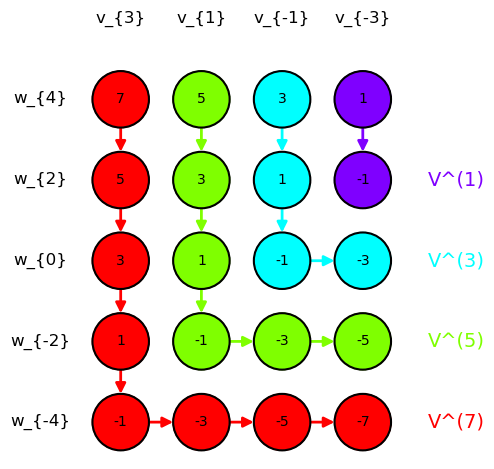

In [31]:
def plot_clebsch_gordan(n, m):
    """
    Visualizes the Clebsch-Gordan decomposition of V^(n) (X) V^(m) 
    as L-shaped paths peeling off irreducible representations on a grid.
    """
    # Ensure n >= m for the grid orientation (rows >= cols)
    flipped = False
    if n < m:
        n, m = m, n
        flipped = True

    p = Graphics()
    
    # Define a distinct color palette for the peeled paths
    colors = rainbow(m + 1)
    
    # Draw the axes labels
    for j in range(m + 1):
        col_w = m - 2*j
        label = f"w_{{{col_w}}}" if not flipped else f"v_{{{col_w}}}"
        p += text(label, (j, 1), color='black', fontsize=12)
        
    for i in range(n + 1):
        row_w = n - 2*i
        label = f"v_{{{row_w}}}" if not flipped else f"w_{{{row_w}}}"
        p += text(label, (-1, -i), color='black', fontsize=12)
        
    # Decompose into irreps V^(n+m-2k) for k in [0, m]
    for k in range(m + 1):
        c = colors[k]
        # The L-shape for component k:
        # Goes down column k from row 0 to row n-k
        # Then goes right along row n-k from col k to col m
        
        path_points = []
        # 1. Down the column
        for i in range(n - k + 1):
            path_points.append((k, -i))
            
        # 2. Right across the row
        for j in range(k + 1, m + 1):
            path_points.append((j, -(n - k)))
            
        # Draw the nodes, weights, and connecting arrows for this irrep!
        for idx in range(len(path_points)):
            x, y = path_points[idx]
            
            # Draw the node
            p += circle((x, y), 0.35, fill=True, color=c, zorder=2)
            p += circle((x, y), 0.35, color='black', thickness=1.5, zorder=3)
            
            # Compute and draw the total weight of this tensor node
            # y is negative, so row is -y
            total_weight = (n - 2*abs(y)) + (m - 2*x)
            p += text(str(total_weight), (x, y), color='black', fontsize=10, zorder=4)
            
            # Draw arrow pointing to the next node in the path (the lowering action within the irrep)
            if idx < len(path_points) - 1:
                nx, ny = path_points[idx + 1]
                # Draw arrow from boundary of current node to boundary of next node
                # To avoid overlapping the circle, we shorten the arrow slightly
                dx, dy = nx - x, ny - y
                mag = sqrt(dx**2 + dy**2)
                shorter_dx = (dx / mag) * (mag - 0.7)
                shorter_dy = (dy / mag) * (mag - 0.7)
                start_x, start_y = x + (dx/mag)*0.35, y + (dy/mag)*0.35
                p += arrow2d((start_x, start_y), (start_x + shorter_dx, start_y + shorter_dy), color=c, width=2, arrowsize=3, zorder=1)
                
        # Add a floating legend text indicating which Irrep this component represents
        weight_of_irrep = n + m - 2*k
        # Draw the legend to the right of the path's terminal node
        p += text(f"V^({weight_of_irrep})", (m + 0.8, -(n - k)), color=c, fontsize=14, horizontal_alignment='left')

    p.axes(False)
    p.set_aspect_ratio(1)
    return p

print("--- Clebsch-Gordan Visualization for V^(4) \\otimes V^(3) ---")
plot_clebsch_gordan(3,4)
